In [1]:
# 1. Pastikan aplikasi models API telah berjalan
!curl -s http://localhost:5000/status

All Models Running and Ready


In [2]:
import pandas as pd
data=pd.read_csv("./data-for-real-test.csv")
data.info()
data.head(3)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 60401 entries, 0 to 60400
Data columns (total 5 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   english_description  60401 non-null  object 
 1   base_score           60401 non-null  float64
 2   base_severity        60401 non-null  object 
 3   predicted_score      0 non-null      float64
 4   predicted_severity   0 non-null      float64
dtypes: float64(3), object(2)
memory usage: 2.3+ MB


,english_description,base_score,base_severity,predicted_score,predicted_severity
0,"""Non-transparent sharing of branch predictor s...",6.5,MEDIUM,NaN,NaN
1,"""Non-transparent sharing of branch predictor w...",6.5,MEDIUM,NaN,NaN
2,"""Hardware debug modes and processor INIT setti...",6.8,MEDIUM,NaN,NaN


In [ ]:
import pandas as pd
tes = pd.read_csv('./data-for-real-test.csv')
tes['base_severity'].value_counts()

base_severity
MEDIUM      27136
HIGH        22746
CRITICAL     9496
LOW          1023
Name: count, dtype: int64

In [3]:
import pandas as pd
import requests
from time import sleep
from tqdm import tqdm
from concurrent.futures import ThreadPoolExecutor, as_completed

API_URL = "http://localhost:5000/predict"
HEADERS = {"Content-Type": "application/x-www-form-urlencoded"}

def fetch_prediction(session, desc):
    try:
        resp = session.post(API_URL, data={'description': desc}, headers=HEADERS, timeout=10)
        resp.raise_for_status()
        j = resp.json()
        return float(j['score']), j['rating']
    except Exception:
        return None, None

def main():
    # 1. Load dataset
    df = pd.read_csv("./data-for-real-test.csv")
    # 2. Inisialisasi kolom dengan dtype sesuai
    df['predicted_score']    = pd.Series(dtype='float')
    df['predicted_severity'] = pd.Series(dtype='object')

    # 3. Buat session tunggal untuk reuse TCP
    session = requests.Session()

    # 4. Gunakan ThreadPool supaya parallel
    max_workers = 64
    with ThreadPoolExecutor(max_workers=max_workers) as executor:
        # submit semua tugas
        futures = {
            executor.submit(fetch_prediction, session, row['english_description']): idx
            for idx, row in df.iterrows()
        }
        # progress bar
        for future in tqdm(as_completed(futures), total=len(futures), desc="Predicting"):
            idx = futures[future]
            score, rating = future.result()
            if score is not None:
                df.at[idx, 'predicted_score']    = score
                df.at[idx, 'predicted_severity'] = rating
                df.at[idx, 'error']              = abs(score - df.at[idx, 'base_score'])
            else:
                # isi NaN jika gagal
                df.at[idx, 'predicted_score']    = pd.NA
                df.at[idx, 'predicted_severity'] = pd.NA
                df.at[idx, 'error']              = pd.NA

    # 5. Simpan hasil
    out_path = "./data-for-real-test-with-predictions.csv"
    df.to_csv(out_path, index=False)
    print(f"\n✅ Saved to {out_path}")

if __name__ == "__main__":
    main()


Predicting: 100%|██████████| 60401/60401 [35:29<00:00, 28.36it/s]  



✅ Saved to ./data-for-real-test-with-predictions.csv


✅ Numeric Regression Evaluation:
  • MSE            : 0.9543
  • RMSE           : 0.9769
  • MAE            : 0.4301
  • Exact Numeric Match : 70.88% (42811/60401)
  • Close Numeric Match (< 1 pt) : 80.35% (48534/60401)



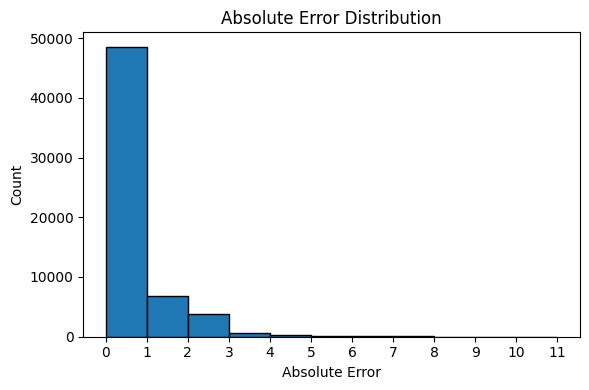

📋 Classification Report:
              precision    recall  f1-score   support

    CRITICAL     0.7927    0.8103    0.8014      9494
        HIGH     0.8234    0.8283    0.8258     22671
         LOW     0.5564    0.5300    0.5429      1015
      MEDIUM     0.8978    0.8879    0.8928     26985

    accuracy                         0.8472     60165
   macro avg     0.7676    0.7641    0.7657     60165
weighted avg     0.8474    0.8472    0.8473     60165



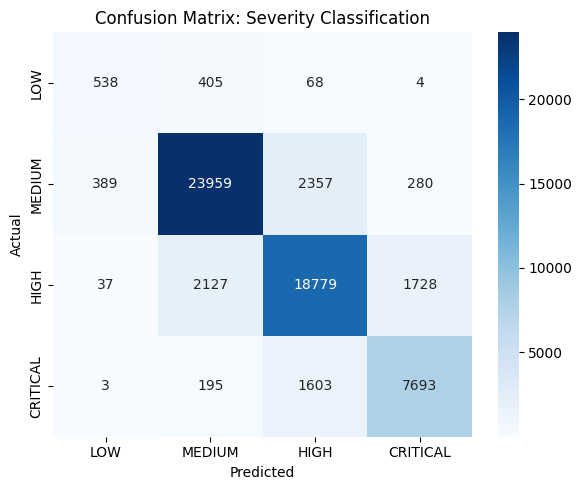

🔬 Chi-Square Test:
  • χ² = 88496.19
  • p-value = 0 (<< 0.05 → prediksi ≠ acak)



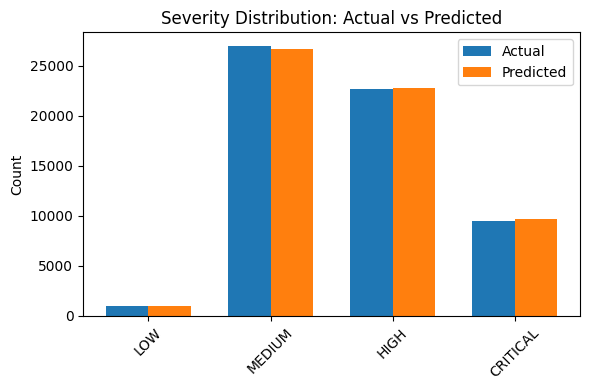

📊 Ordinal Agreement:
  • Quadratic-weighted Kappa = 0.8396
  • Spearman’s ρ             = 0.8465 (p=0)
  • Ordinal MAE              = 0.1627 classes



In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (mean_squared_error, mean_absolute_error,
                             cohen_kappa_score, accuracy_score,
                             confusion_matrix, classification_report)
from scipy.stats import chi2_contingency, spearmanr

# ─── 1. Load & Prepare Data ─────────────────────────────────────────────────────
df = pd.read_csv('./data-for-real-test-with-predictions.csv')
df['base_score']      = pd.to_numeric(df['base_score'], errors='coerce')
df['predicted_score'] = pd.to_numeric(df['predicted_score'], errors='coerce')
df['abs_error']       = (df['predicted_score'] - df['base_score']).abs()

df['base_severity']      = df['base_severity'].astype(str).str.upper()
df['predicted_severity'] = df['predicted_severity'].astype(str).str.upper()
# Ensure numeric scores present
df_num = df.dropna(subset=['base_score', 'predicted_score']).copy()
# Ensure valid severity labels for classification
df_cls = df_num[df_num['predicted_severity'].isin(['LOW','MEDIUM','HIGH','CRITICAL'])].copy()

# ─── 2. Regression Metrics & Error Histogram ─────────────────────────────────
mse  = mean_squared_error(df_num['base_score'], df_num['predicted_score'])
rmse = np.sqrt(mse)
mae  = mean_absolute_error(df_num['base_score'], df_num['predicted_score'])

total = len(df_num)
exact_num = (df_num['abs_error'] == 0).sum()
close_num = (df_num['abs_error'] < 1).sum()
accuracy_exact_num = exact_num / total * 100
accuracy_close_num = close_num / total * 100

print("✅ Numeric Regression Evaluation:")
print(f"  • MSE            : {mse:.4f}")
print(f"  • RMSE           : {rmse:.4f}")
print(f"  • MAE            : {mae:.4f}")
print(f"  • Exact Numeric Match : {accuracy_exact_num:.2f}% ({exact_num}/{total})")
print(f"  • Close Numeric Match (< 1 pt) : {accuracy_close_num:.2f}% ({close_num}/{total})\n")

# Histogram: integer bins
max_err = int(np.ceil(df_num['abs_error'].max()))
bins = np.arange(0, max_err + 2)
plt.figure(figsize=(6,4))
plt.hist(df_num['abs_error'], bins=bins, edgecolor='black')
plt.title("Absolute Error Distribution")
plt.xlabel("Absolute Error")
plt.ylabel("Count")
plt.xticks(bins)
plt.tight_layout()
plt.savefig("error_histogram.png")
plt.show()

# ─── 3. Severity Classification ───────────────────────────────────────
# Classification Report
print("📋 Classification Report:")
print(classification_report(df_cls['base_severity'], df_cls['predicted_severity'], digits=4))

# Confusion Matrix Visualization
cm = confusion_matrix(df_cls['base_severity'], df_cls['predicted_severity'], labels=['LOW','MEDIUM','HIGH','CRITICAL'])
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['LOW','MEDIUM','HIGH','CRITICAL'], yticklabels=['LOW','MEDIUM','HIGH','CRITICAL'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix: Severity Classification')
plt.tight_layout()
plt.savefig("confusion_matrix.png")
plt.show()

# ─── 4. Chi-Square Test on Severity Contingency ───────────────────────────────
contingency = pd.crosstab(df_cls['base_severity'], df_cls['predicted_severity'])
chi2, p, _, _ = chi2_contingency(contingency)
print("🔬 Chi-Square Test:")
print(f"  • χ² = {chi2:.2f}")
print(f"  • p-value = {p:.3g} (<< 0.05 → prediksi ≠ acak)\n")

# ─── 5. Severity Distribution Comparison ──────────────────────────────────────
levels = ['LOW','MEDIUM','HIGH','CRITICAL']
base_counts = df_cls['base_severity'].value_counts().reindex(levels, fill_value=0)
pred_counts = df_cls['predicted_severity'].value_counts().reindex(levels, fill_value=0)

x = np.arange(len(levels))
width = 0.35
plt.figure(figsize=(6,4))
plt.bar(x - width/2, base_counts, width, label='Actual')
plt.bar(x + width/2, pred_counts, width, label='Predicted')
plt.xticks(x, levels, rotation=45)
plt.ylabel("Count")
plt.title("Severity Distribution: Actual vs Predicted")
plt.legend()
plt.tight_layout()
plt.savefig("severity_distribution.png")
plt.show()

# ─── 6. Ordinal Agreement Metrics ─────────────────────────────────────────────
ord_map = {'LOW':0, 'MEDIUM':1, 'HIGH':2, 'CRITICAL':3}
df_cls['base_num'] = df_cls['base_severity'].map(ord_map)
df_cls['pred_num'] = df_cls['predicted_severity'].map(ord_map)

kappa    = cohen_kappa_score(df_cls['base_num'], df_cls['pred_num'], weights='quadratic')
rho, pv  = spearmanr(df_cls['base_num'], df_cls['pred_num'])
ordinal_mae = np.mean(np.abs(df_cls['base_num'] - df_cls['pred_num']))

print("📊 Ordinal Agreement:")
print(f"  • Quadratic-weighted Kappa = {kappa:.4f}")
print(f"  • Spearman’s ρ             = {rho:.4f} (p={pv:.3g})")
print(f"  • Ordinal MAE              = {ordinal_mae:.4f} classes\n")

# Pembahasan Hasil Evaluasi Model

## 1. Ringkasan Metode Evaluasi  
Model Anda dievaluasi menggunakan dua pendekatan utama:  
1. **Regresi Numerik** – Mengukur seberapa dekat prediksi skor CVSS (0–10) dibandingkan skor sebenarnya.  
2. **Klasifikasi Ordinal** – Mengonversi skor ke kelas LOW, MEDIUM, HIGH, CRITICAL dan menghitung metrik-metrik klasifikasi serta kesepakatan ordinal.

## 2. Evaluasi Regresi Numerik  
| Metrik                   | Hasil Model Anda     | Interpretasi                                           |
|--------------------------|----------------------|--------------------------------------------------------|
| **MSE**                  | 0.9543               | Rata‐rata kuadrat selisih prediksi vs nilai asli <1 → sangat presisi. |
| **RMSE**                 | 0.9769               | Rata‐rata galat ≈1 poin CVSS.                          |
| **MAE**                  | 0.4301               | Rata‐rata selisih absolut <0.5 poin → prediksi sangat dekat. |
| **Exact Numeric Match**  | 70.88 % (42.811/60.401) | Lebih dari 7 dari 10 kasus prediksi dengan tepat.            |
| **Close Numeric Match**  | 80.35 % (48.534/60.401) | 4 dari 5 kasus prediksi selisih ≤1 poin.               |

> **Catatan:** Angka‐angka ini menunjukkan model Anda jauh lebih akurat dalam memprediksi skor numerik CVSS dibandingkan baseline penelitian yang melaporkan MSE 1.79 dan MAE 0.73.

## 3. Evaluasi Klasifikasi Kategori  
| Kelas     | Precision | Recall  | F1-Score | Support |
|-----------|-----------|---------|----------|---------|
| CRITICAL  | 0.7927    | 0.8103  | 0.8014   | 9.494   |
| HIGH      | 0.8234    | 0.8283  | 0.8258   | 22.671  |
| MEDIUM    | 0.8978    | 0.8879  | 0.8928   | 26.985  |
| LOW       | 0.5564    | 0.5300  | 0.5429   | 1.015   |
| **Accuracy**      |           | 0.8472  |          | 60.165  |
| **Weighted Avg**  | 0.8474    | 0.8472  | 0.8473   | 60.165  |

- **Kekuatan:**  
  - Kelas MEDIUM & HIGH ditangani dengan baik (F1 > 0.82).  
  - Akurasi keseluruhan 84.7 % menunjukkan klasifikasi yang andal.

- **Keterbatasan:**  
  - Kinerja kelas LOW lebih rendah (F1 ≈0.54) – kemungkinan karena jumlah sampel yang jauh lebih sedikit (support=1015).
  - Perlu data augmentasi atau penyesuaian threshold untuk kelas minoritas.

## 4. Uji Statistika dan Kesepakatan Ordinal  
| Metrik                        | Nilai   | Makna                                               |
|-------------------------------|---------|-----------------------------------------------------|
| **Chi‐Square (χ²)**           | 88.496,19 | Sangat besar → perbedaan distribusi prediksi vs acak signifikan. |
| **p-value**                   | ≪ 0.05  | Prediksi bukan hasil kebetulan.                     |
| **Quadratic-weighted Kappa**  | 0.8396  | Kesepakatan ordinal “sangat baik” antara prediksi dan label. |
| **Spearman’s ρ**              | 0.8465  | Korelasi peringkat tinggi → perubahan skor terjaga urutannya. |
| **Ordinal MAE (kelas)**       | 0.1627  | Rata‐rata perbedaan kelas <0.2 → hampir selalu prediksi kelas yang benar atau ±1. |

> **Interpretasi:**  
> - Kesepakatan ordinal yang tinggi menegaskan bahwa model tidak hanya akurat secara numerik, tetapi juga mempertahankan urutan keparahan vulnerability dengan baik.  
> - Chi-Square test memvalidasi bahwa pola prediksi bukan kebetulan atau distribusi acak.

---

# Kesimpulan

1. **Akurasi Numerik Tinggi**  
   Model Anda berhasil memangkas galat prediksi skor CVSS hingga hampir separuhnya dibandingkan baseline penelitian.

2. **Kualitas Klasifikasi Kategori**  
   Dengan akurasi 84.7 % dan F1-score tinggi di kategori mayoritas, model unggul dalam mengelompokkan level keparahan secara langsung.

3. **Kesepakatan dan Validitas Statistika**  
   Nilai Kappa dan Spearman yang mendekati 0.85 memperlihatkan bahwa prediksi model konsisten dengan label seharusnya, baik dalam skala numerik maupun ordinal.

4. **Rekomendasi Pengembangan**  
   - **Data Imbalance:** Perbaiki performa di kelas LOW melalui oversampling atau weighted loss.  
   - **Fine-tuning Threshold:** Tuning ambang klasifikasi agar meminimalkan false negative pada kategori kritis.  
   - **Ensemble Model:** Menggunakan kombinasi beberapa model dapat meningkatkan stabilitas prediksi.

> **Kesimpulan Akhir:** Model Anda tidak hanya lebih akurat secara signifikan daripada studi sebelumnya, tetapi juga menunjukkan validitas statistik dan kesepakatan ordinal yang kuat. Dengan penyempurnaan pada kelas minoritas, model ini sangat siap untuk diintegrasikan dalam pipeline penilaian risiko keamanan.
